In [1]:
import pandas as pd
import tarfile
import numpy as np
import pickle
import io
import itertools
from collections import Counter, defaultdict
import sys
import glob
# from gtda.diagrams import PersistenceImage
# from gtda.plotting import plot_heatmap
import dionysus
import numpy as np
from scipy.stats import multivariate_normal

In [8]:
def set_atgcx_5(data):
    rgb_atgcx = []
    # for data in all_node_counts_list:
    if len(data) > 0:
        a_val = data.get('a', 0)
        t_val = data.get('t', 0)
        g_val = data.get('g', 0)
        c_val = data.get('c', 0)
        x_val = data.get('x', 0)

        total = sum(data.values())
        a = (a_val / total) #* 255
        t = (t_val / total) #* 255
        g = (g_val / total) #* 255
        c = (c_val / total) #* 255
        x = (x_val / total) #* 255

        rgb_atgcx.append([a,t,g,c,x])
    else:
        rgb_atgcx.append([0,0,0,0,0])
    return rgb_atgcx

def get_nodes_and_edges(seq, k, l=1):
    # Get nodes
    nodes = [seq[i:i+k] for i in range(len(seq)-k+1)]

    # Get the edges
    edges = []
    for i in range(len(nodes) - l):
        a = nodes[i]
        b = nodes[i + l]
        edge = tuple((a, b))
        edges.append(edge)

    return nodes, edges

    
def extract_relevant_cc(seq, ccs, k):
    results = []
    # Iterate through the sequence to find CC actually in it
    nodes, _ = get_nodes_and_edges(seq=seq, k=k) # Get nodes

    # Iterate through the ccs and find which are in the seq
    for cc in set(ccs):
        cc_set = set(cc)
        window_size = len(cc_set) + 1

        i = 0
        while i <= len(nodes) - window_size:
            window = nodes[i : i + window_size]
            window_set = set(window)
            
            if window_set == cc_set:
                start_idx = i
                current_end = i + window_size
                
                # Greedy expansion
                while current_end < len(nodes) and set(nodes[start_idx : current_end + 1]) == cc_set:
                    current_end += 1
                
                # Went through entire sequence and found nothing
                if current_end > len(nodes) or nodes[start_idx] != nodes[current_end - 1]:
                    i += 1  # Standard step forward to keep looking
                    continue

                # Fast-forward 'i' past this completed, closed loop structure
                i = current_end 
                results.append(tuple(sorted(cc_set)))
            else:
                i += 1
    return results

def get_cc_b_d(seq, results, barcodes, ccs):
    current_compositions = []
    current_b_d_points = []

    for bd, cc in zip(barcodes, ccs):
        if len(bd) == 0:
            continue
        elif cc in list(set(results)):
            birth, death = bd
            if death == np.inf:
                death = len(seq)
            current_b_d_points.append([birth, death])
        
        # Get composition of cc
        combined_string = "".join(list(cc))
        node_counts = dict(Counter(combined_string))
        
        feature_composition = set_atgcx_5(node_counts) #get fractions
        current_compositions.append(feature_composition[0])
        
    sequence_diagram = np.array(current_b_d_points) #(N,2)
    sequence_compositions = np.array(current_compositions) #(N,5)

    return sequence_diagram, sequence_compositions

def create_PI(sequence_diagram, sequence_compositions, resolution=128, sigma=300):
    N = sequence_diagram.shape[0]

    # Calculate persistences
    births = sequence_diagram[:, 0]
    persistences = sequence_diagram[:, 1] - sequence_diagram[:, 0]

    # Max persistence and birth values
    max_p = persistences.max()
    range_birth = (0, births.max())
    range_persistence = (0, max_p)

    # Grids
    b_grid = np.linspace(0, range_birth[1], resolution)
    p_grid = np.linspace(0, range_persistence[1], resolution)
    B_mesh, P_mesh = np.meshgrid(b_grid, p_grid)
    grid_coords = np.dstack((B_mesh, P_mesh))

    # Empty 5 channel PI
    five_channel_pi = np.zeros((resolution, resolution, 5))

    # Gaussian distribution kernel
    for i in range(N):
        b_pt = births[i] #0
        p_pt = persistences[i] #1
        
        if p_pt <= 0:  # Skip negative
            continue
            
        # CC fractions
        comp_vector = sequence_compositions[i] 
        
        # Gaussian
        rv = multivariate_normal([b_pt,p_pt], [[sigma, 0], [0, sigma]])
        pdf_slice = rv.pdf(grid_coords)
        gaussian_kernel = pdf_slice.reshape(resolution, resolution)

        # Base localized persistence intensity
        base_intensity = p_pt * gaussian_kernel
        
        # Distribute base intensity across channels scaled by nucleotide composition
        for channel_idx in range(5):
            five_channel_pi[:, :, channel_idx] += base_intensity * comp_vector[channel_idx]
            
    if five_channel_pi.max() > 0:
        five_channel_pi = five_channel_pi / five_channel_pi.max()

    return five_channel_pi

In [9]:
path = '/Users/levisvaren/Downloads/040326/051926/'
filename = 'chunk_24.tar.gz'
k = 4

target_dict_name = 'results'

resolution = 128
sigma = 300
persistence_images = {}

with tarfile.open(f"{path}/{filename}", "r:gz") as tar:
    for member in tar:

        if target_dict_name in member.name and member.isfile():
            pkl_file = tar.extractfile(member)

            if pkl_file:
                obj = pickle.load(pkl_file)
                
                # Get barcode and sequence
                for seq, value in obj.items():
                    l = len(seq)

                    barcodes = list(value[0]['barcode_H1'])

                    if len(barcodes) > 0:
                        elements = list(value[0]['barcode_elements_H1'])
                        node_id = value[0]['node_id']
                        id_to_node = {v:k for k,v in node_id.items()}

                        ccs = [tuple(id_to_node[num] for num in t) for t in elements]

                        if len(ccs) == 0:
                            five_channel_pi = np.zeros((resolution, resolution, 5))
                            persistence_images[seq] = {'persistence_image': five_channel_pi}
                            continue

                        ###########
                        for i_seq, k_seq in enumerate([seq]):
                            results = extract_relevant_cc(k_seq, ccs, k)
                        sequence_diagram, sequence_compositions = get_cc_b_d(seq, results, barcodes, ccs)
                        five_channel_pi = create_PI(sequence_diagram, sequence_compositions, resolution=resolution, sigma=sigma)

                    elif len(barcodes) == 0:
                        five_channel_pi = np.zeros((resolution, resolution, 5)) #Empty PI if no CCs

                    persistence_images[seq] = {'persistence_image': five_channel_pi}

KeyboardInterrupt: 

/var/folders/rs/jrxh2nk134sf41fhr94x81s80000gn/T/ipykernel_86434/4236198560.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 5, figsize=(20, 5))


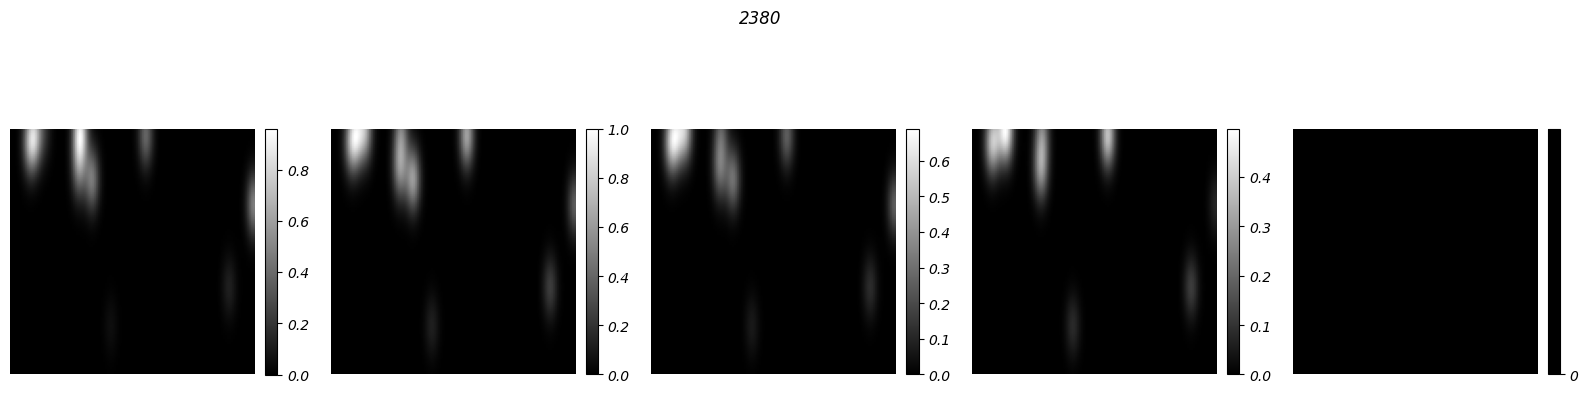

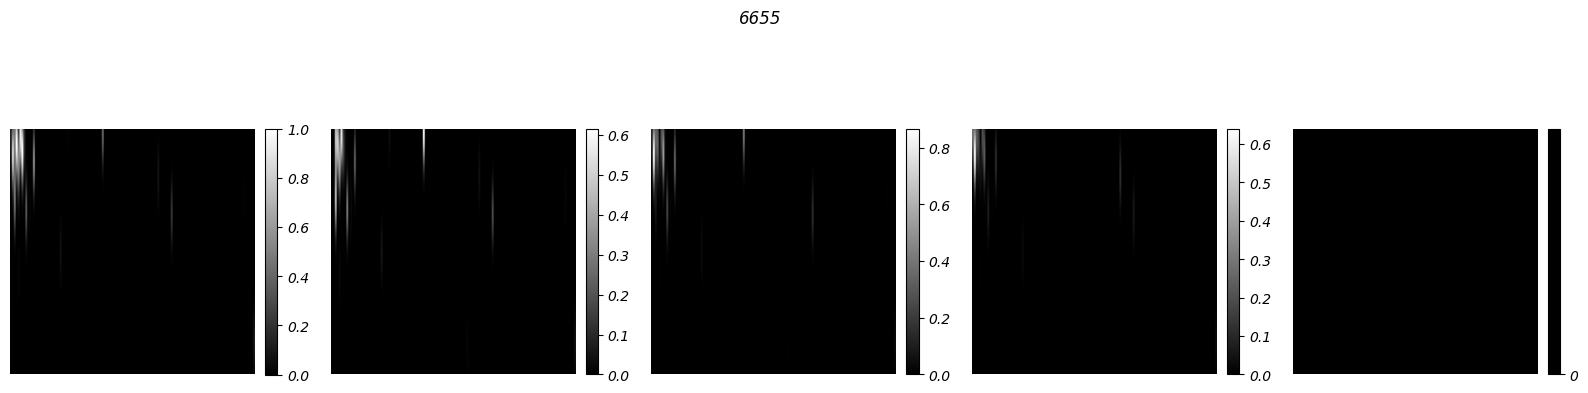

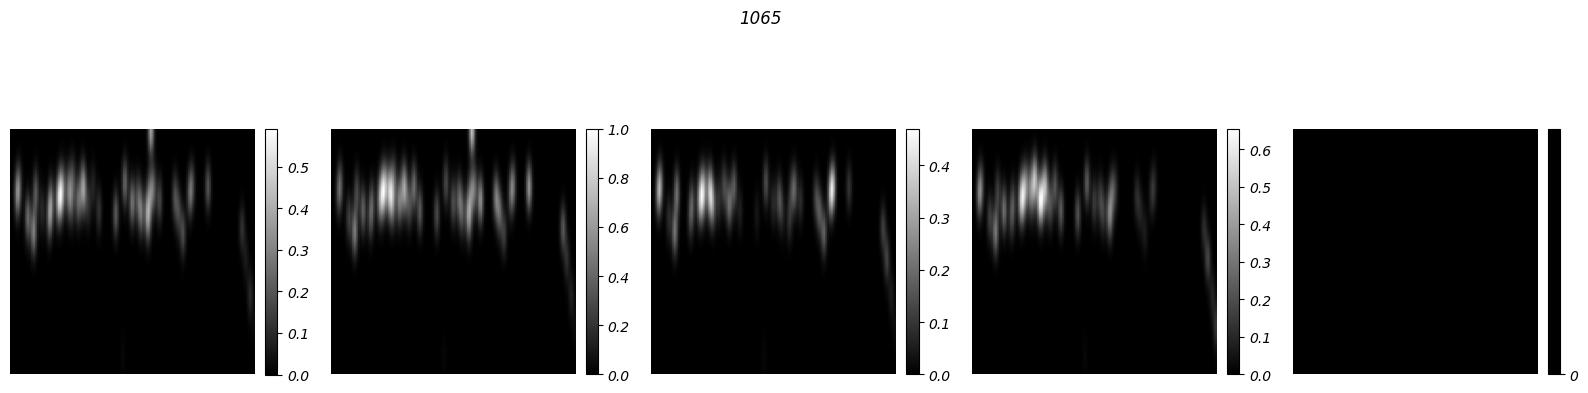

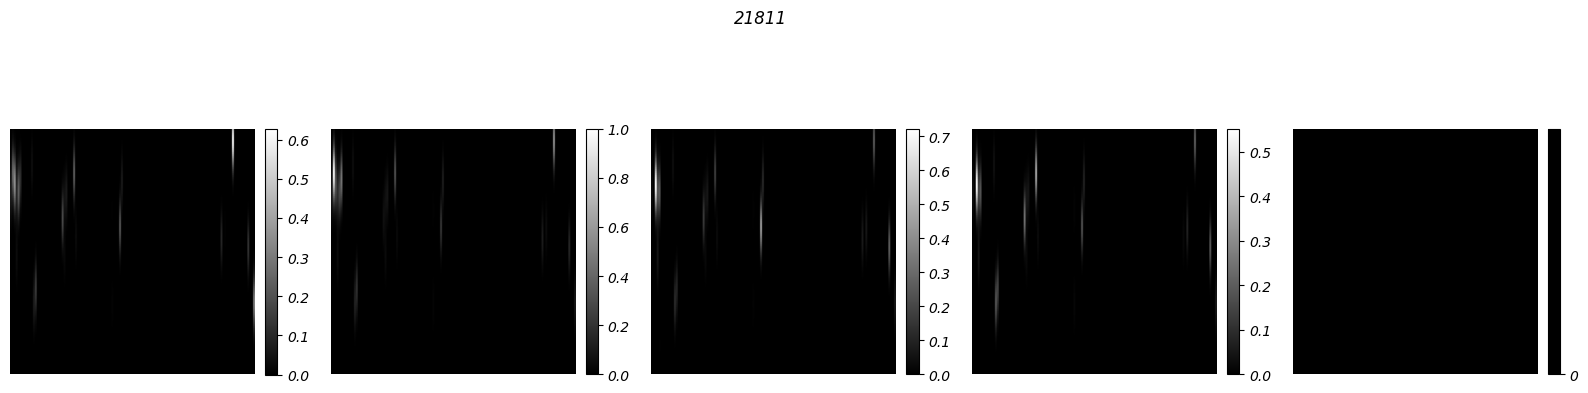

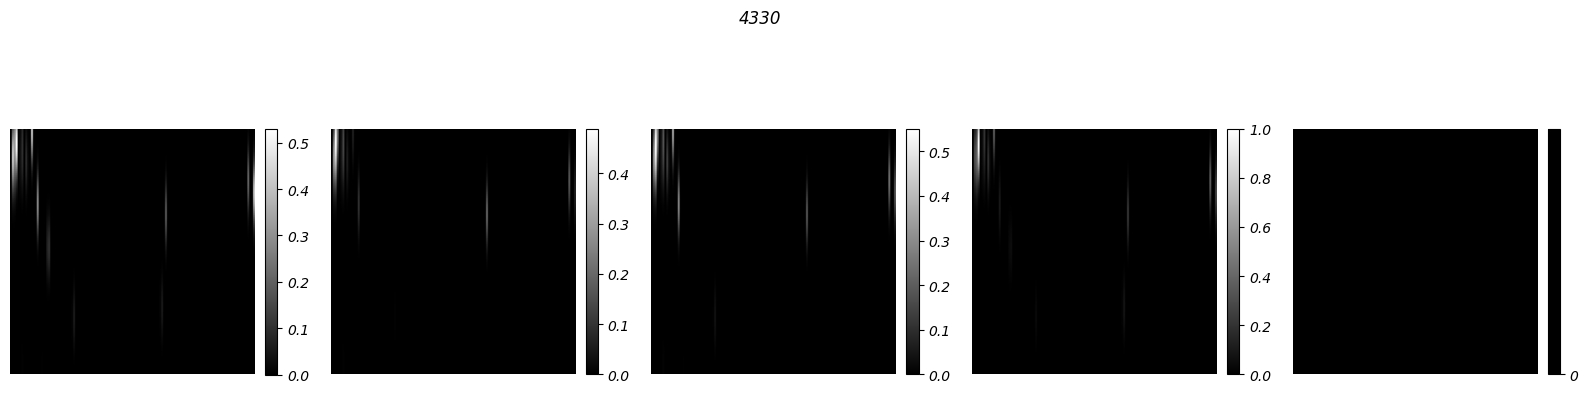

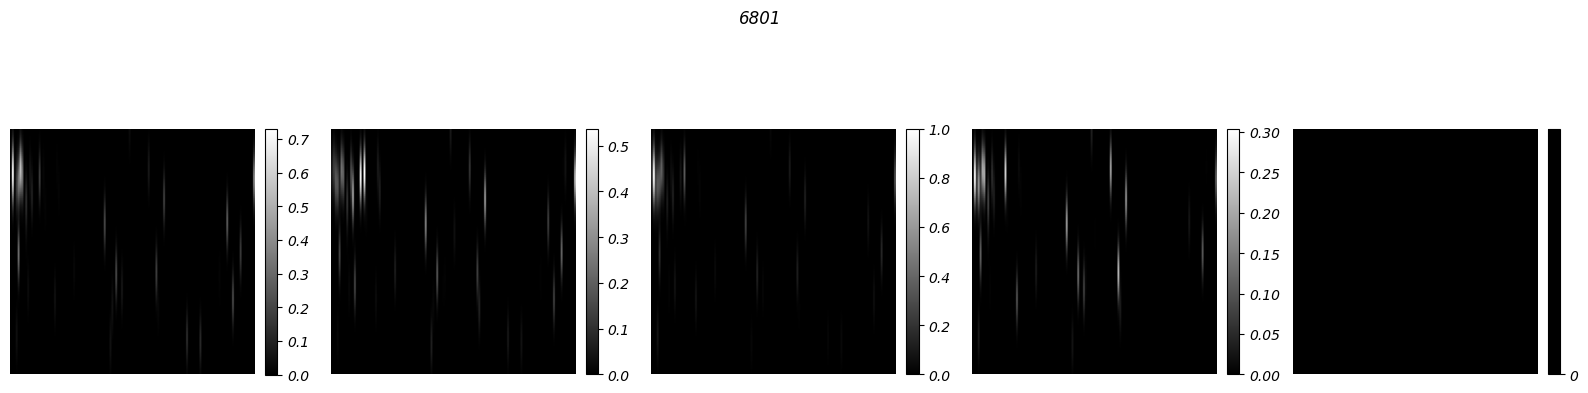

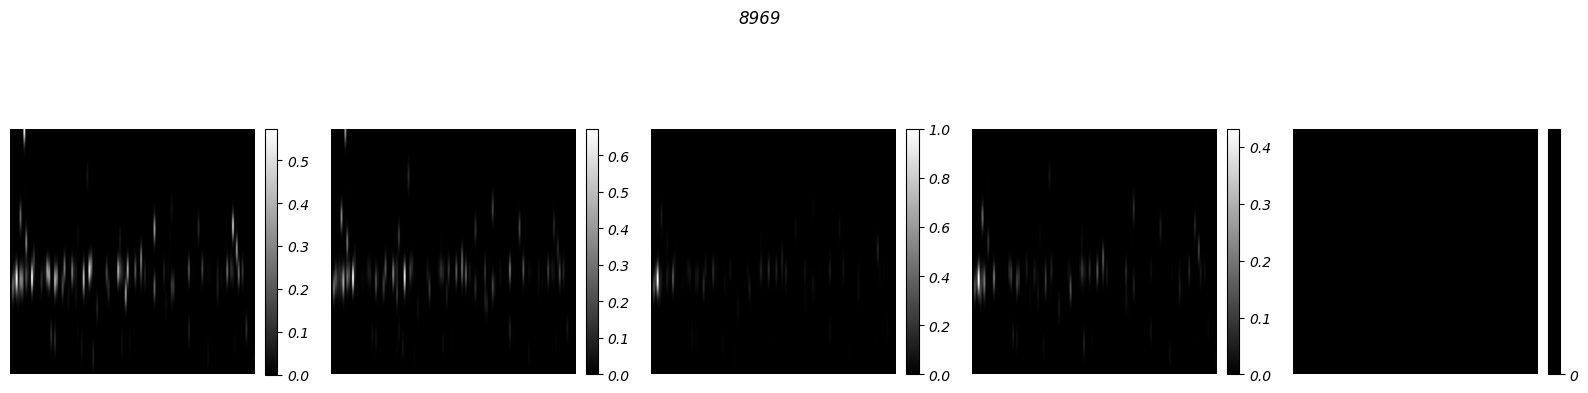

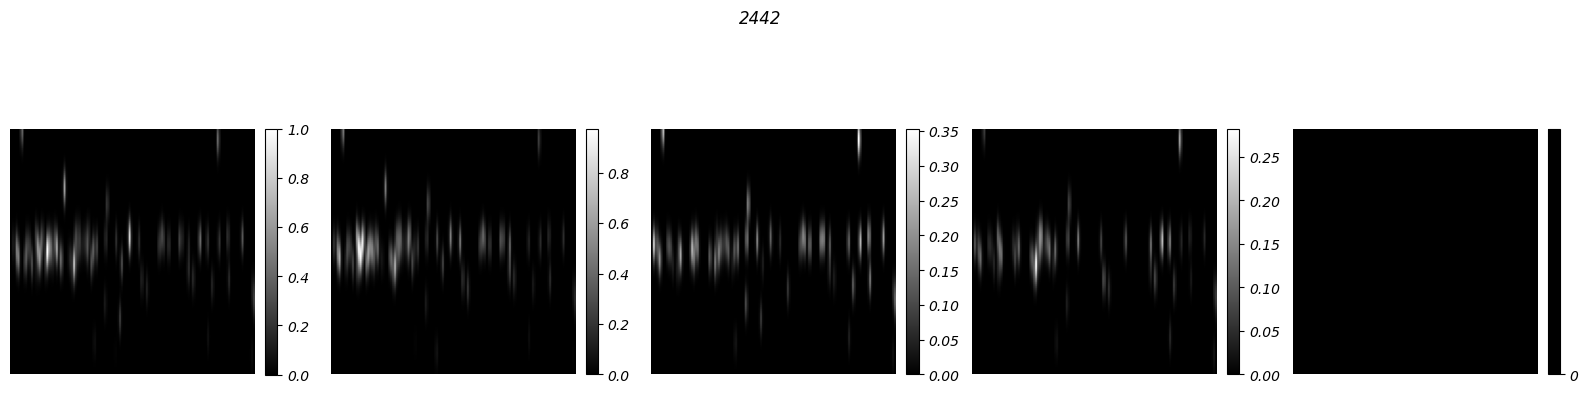

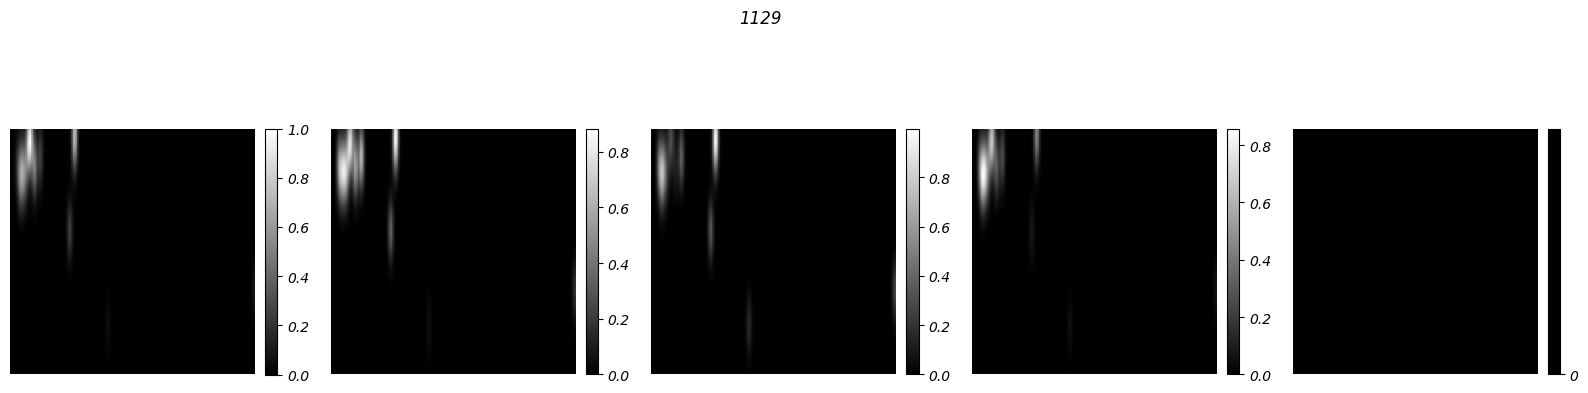

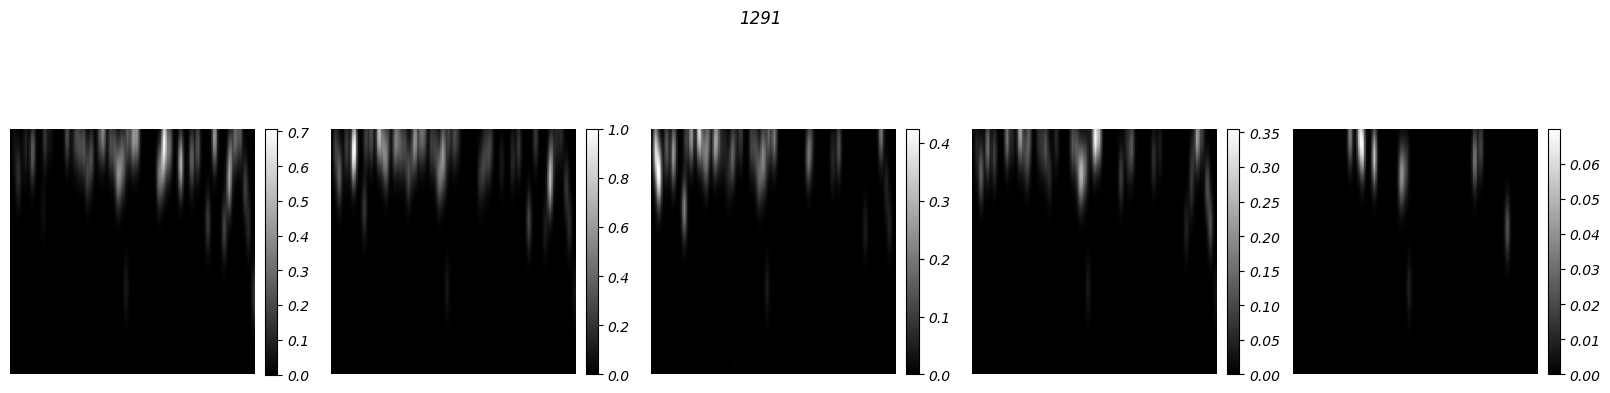

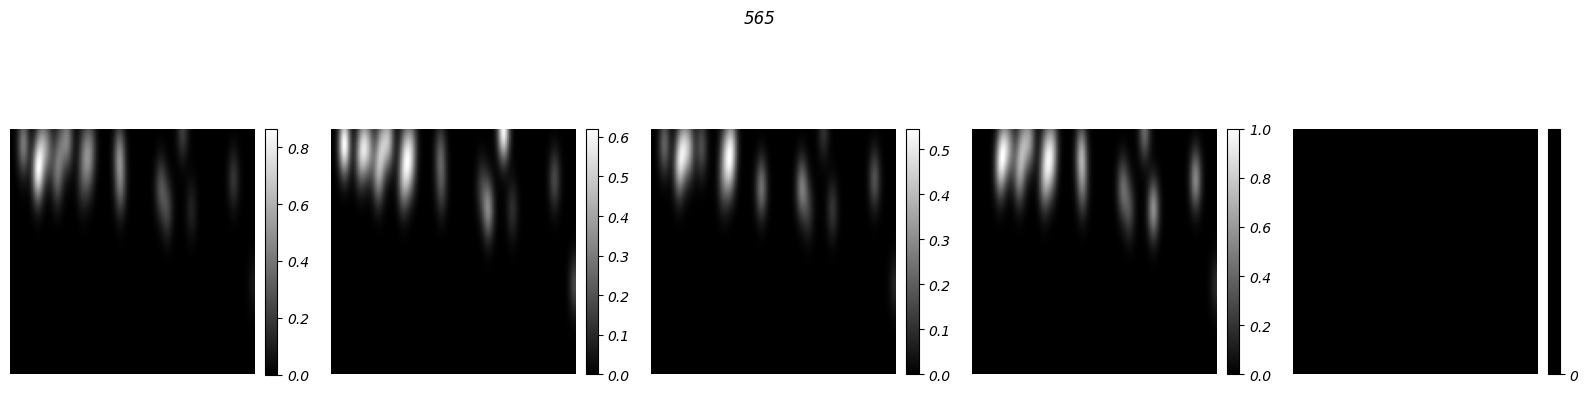

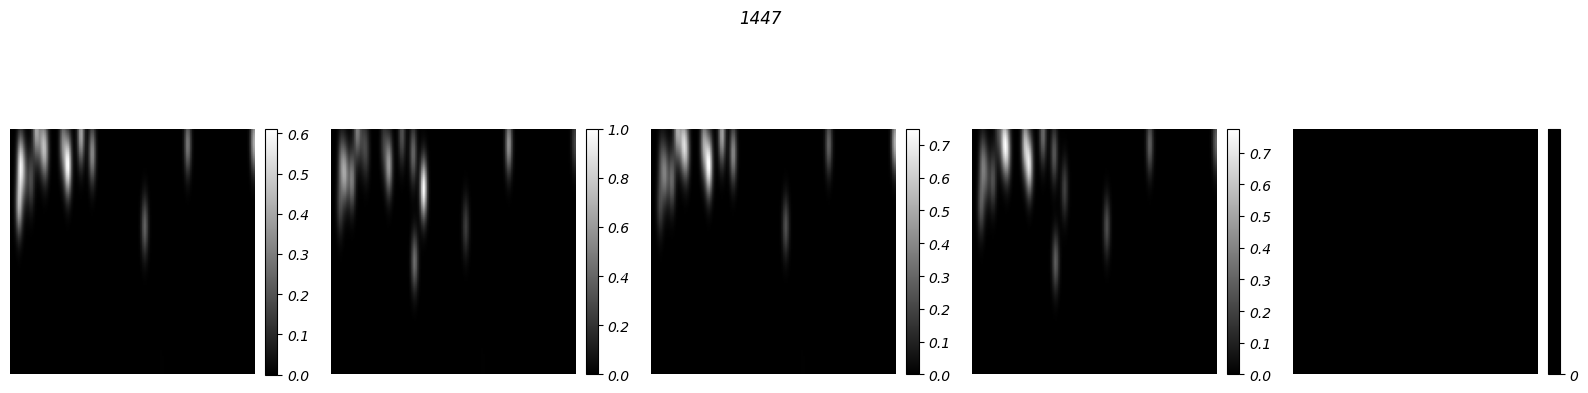

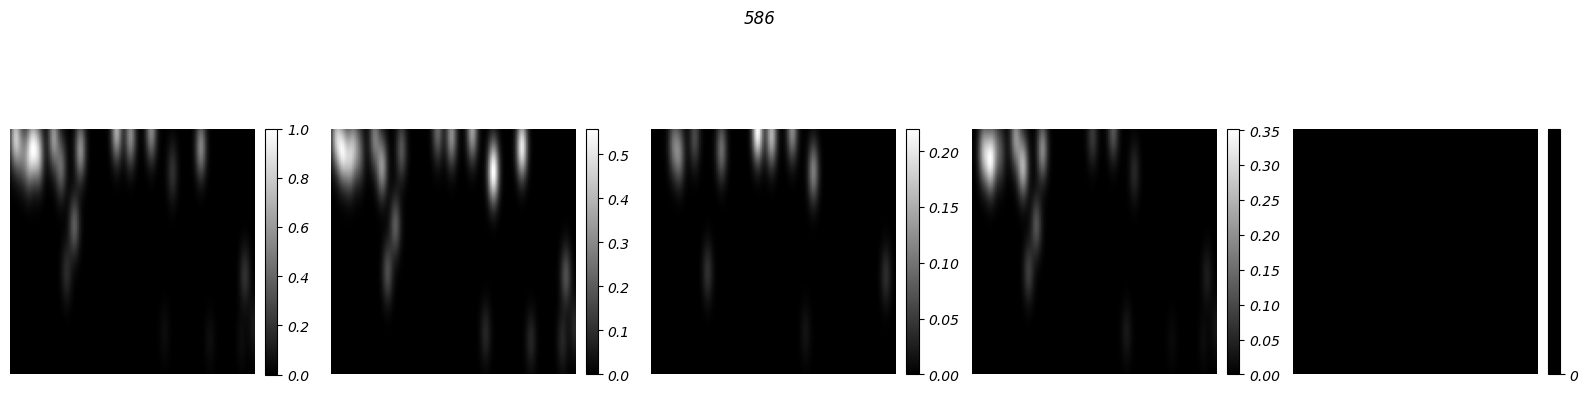

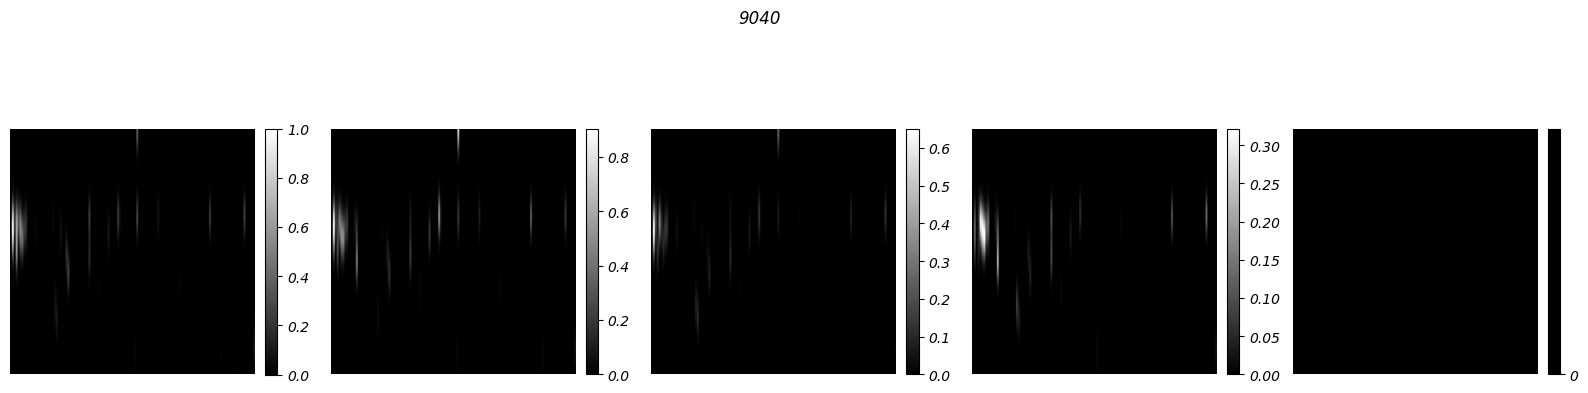

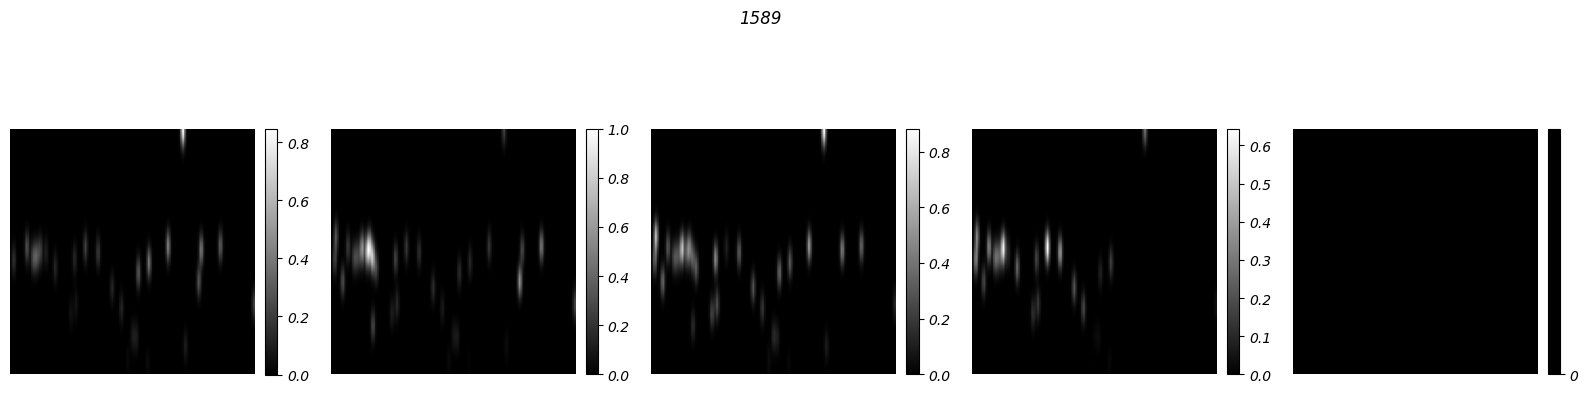

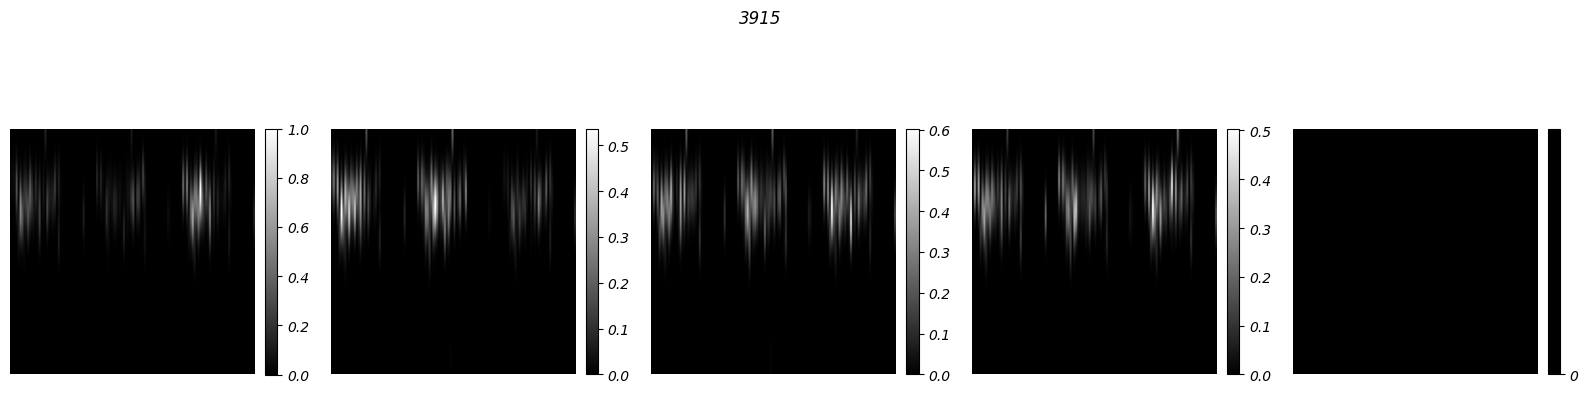

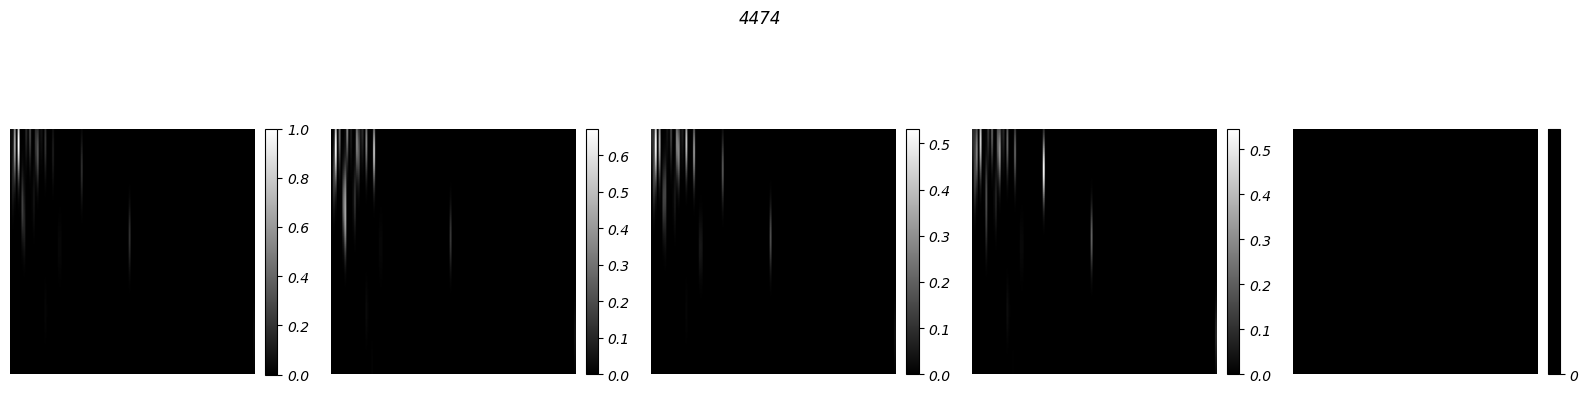

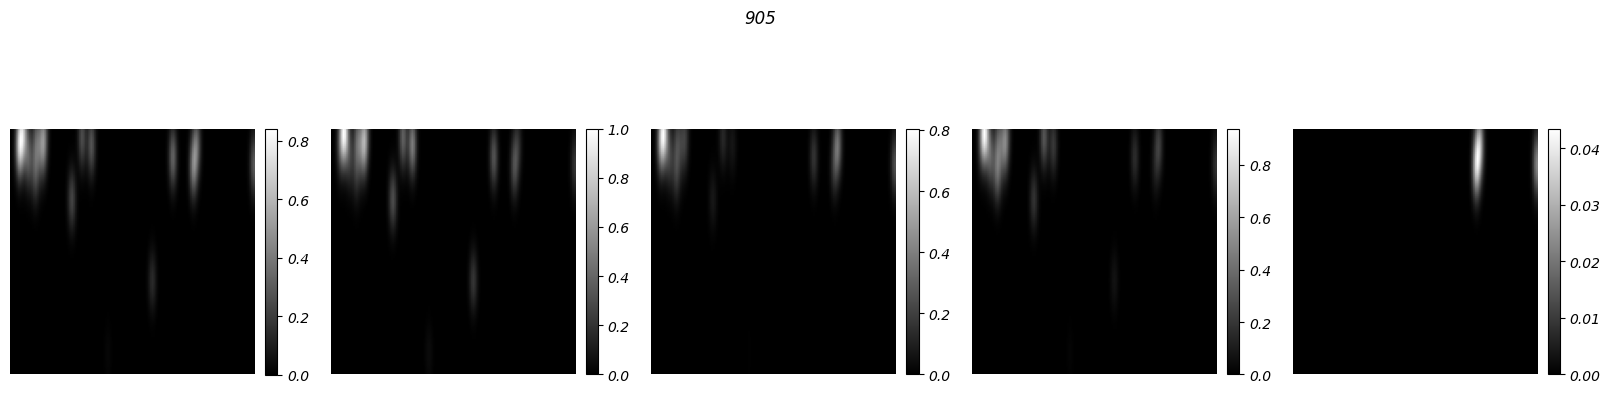

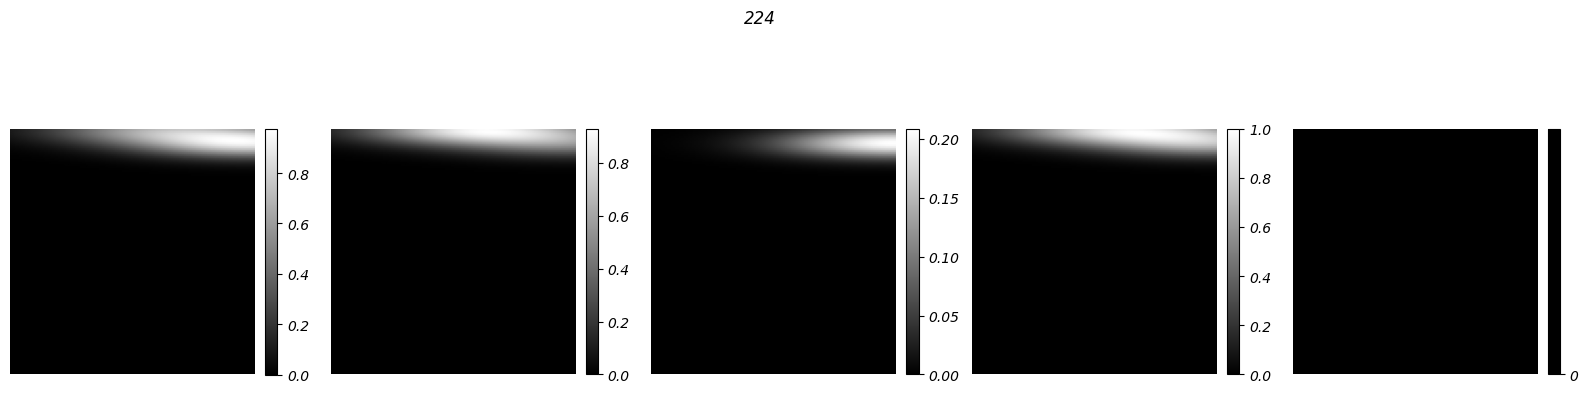

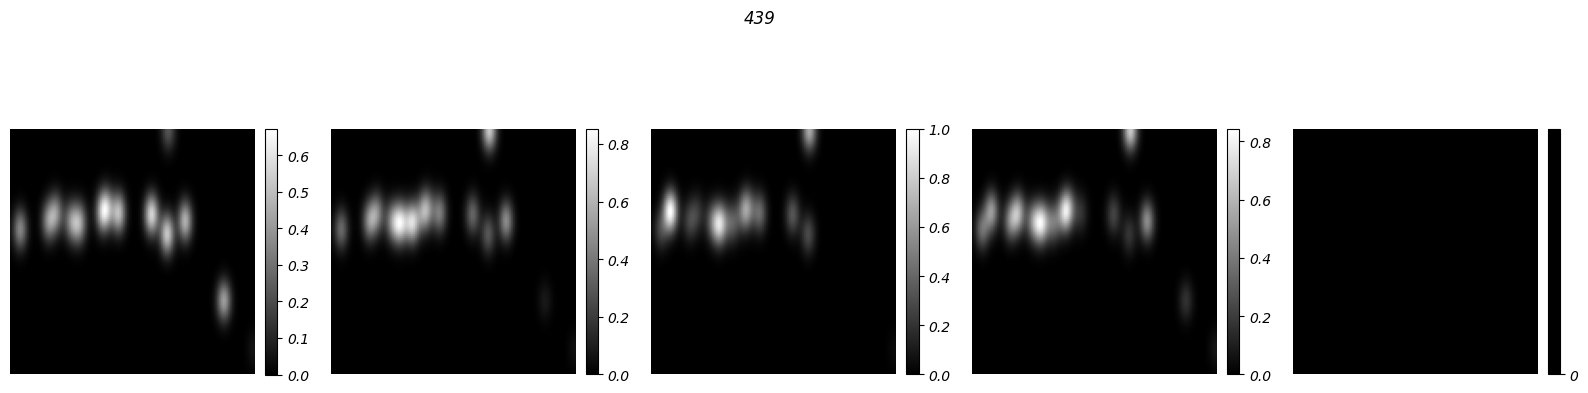

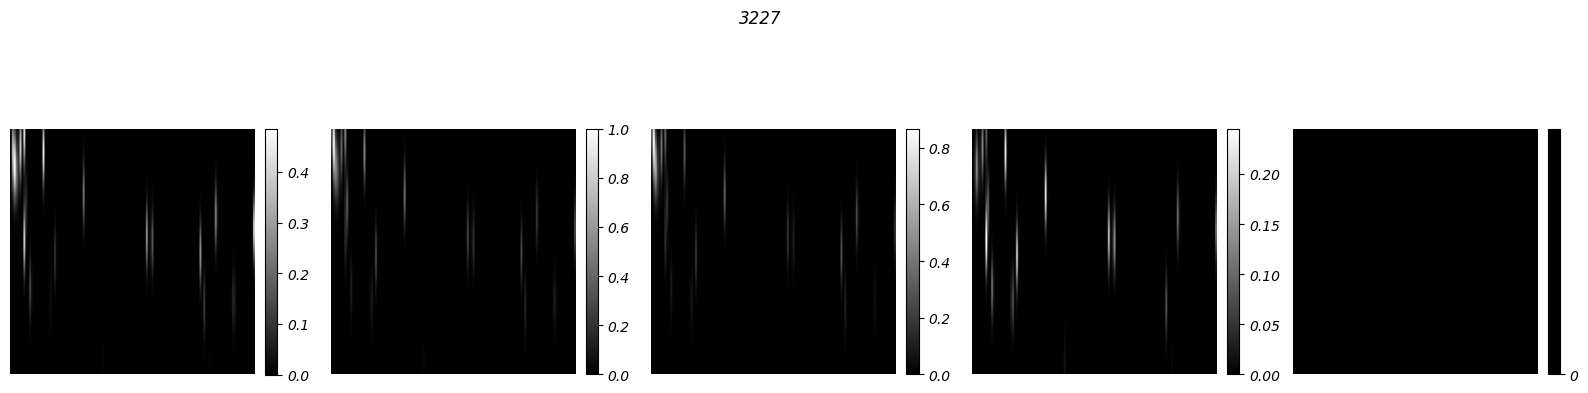

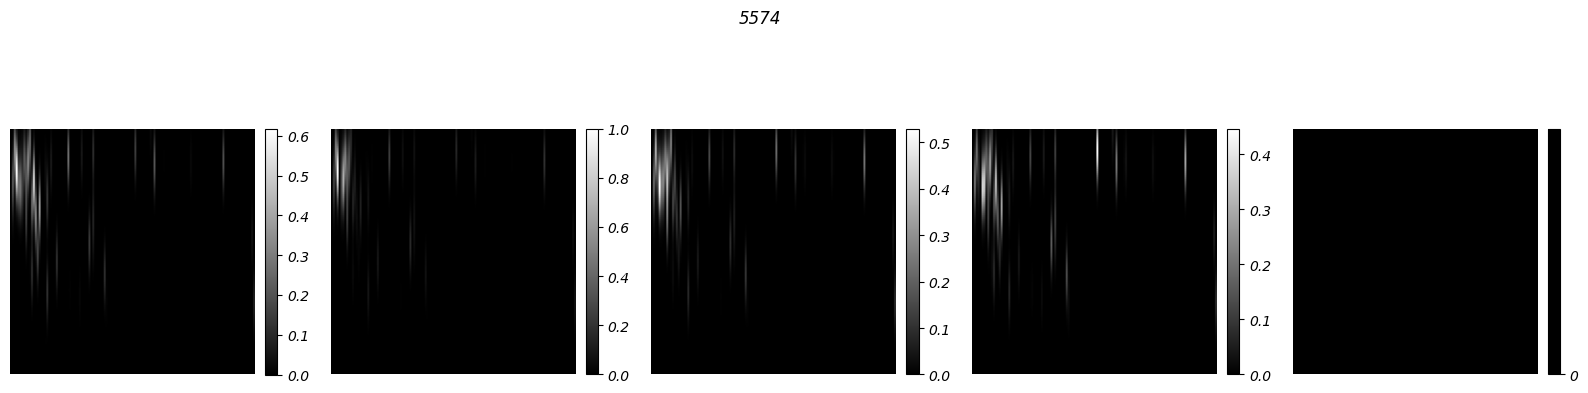

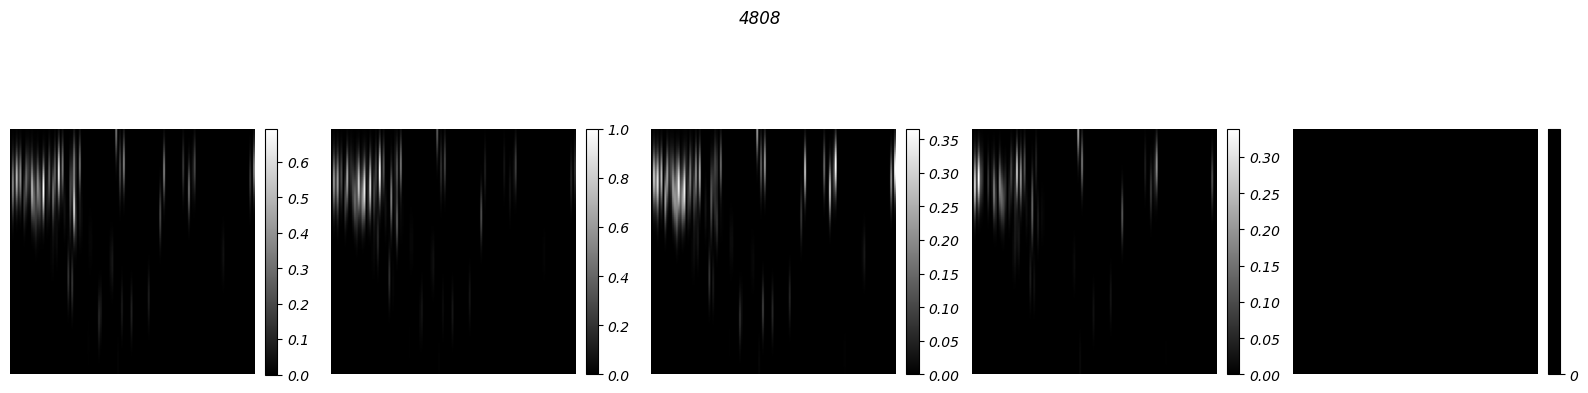

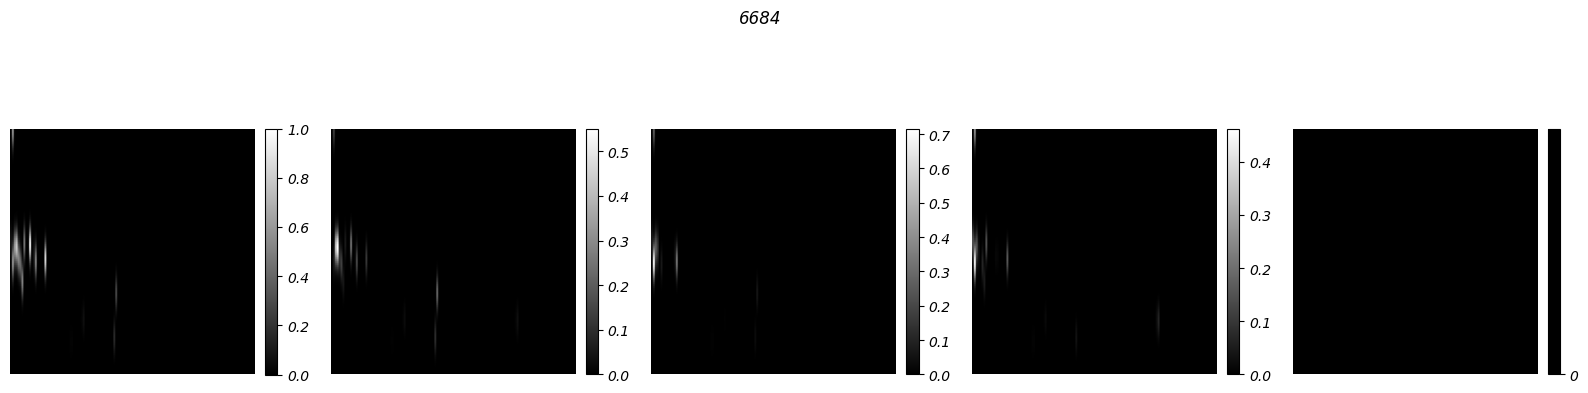

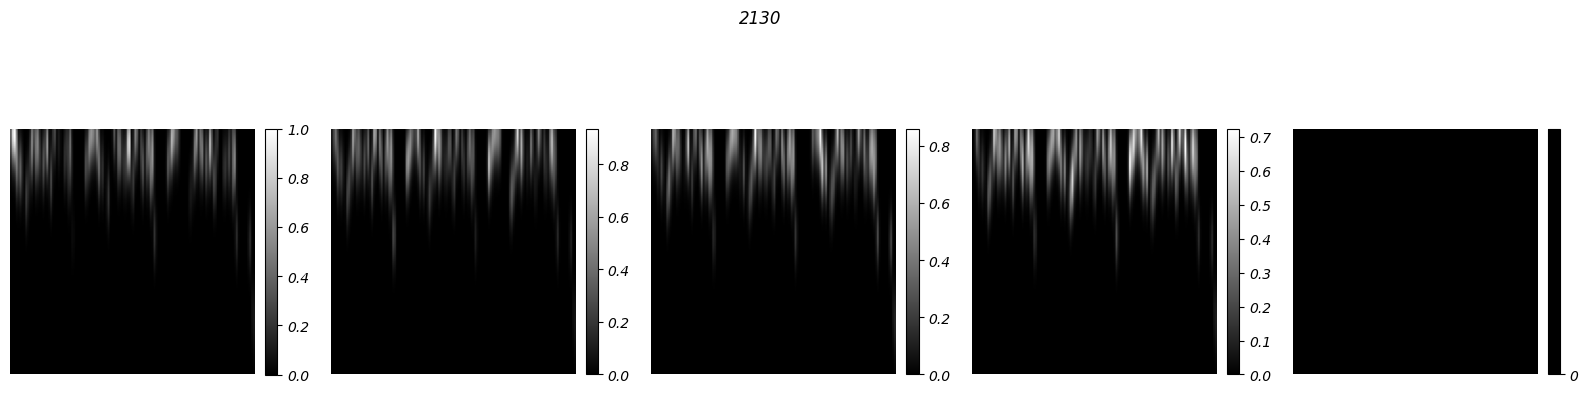

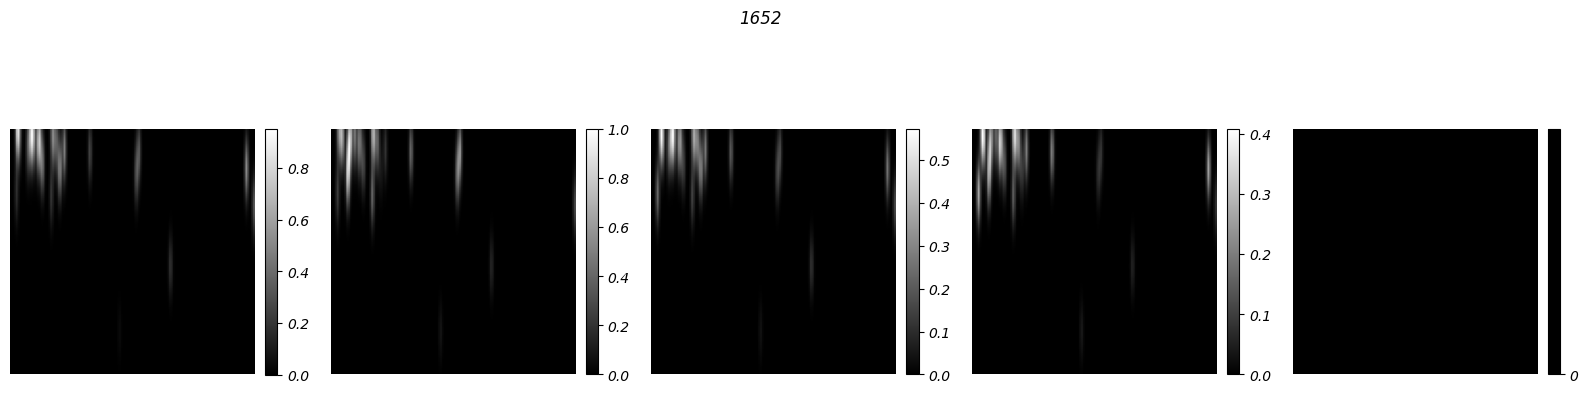

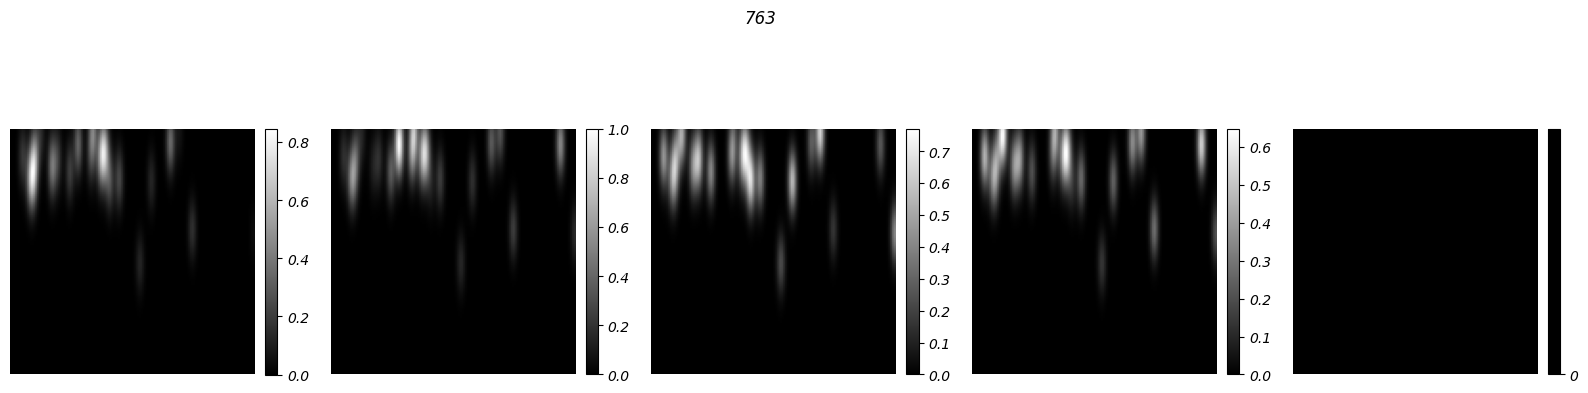

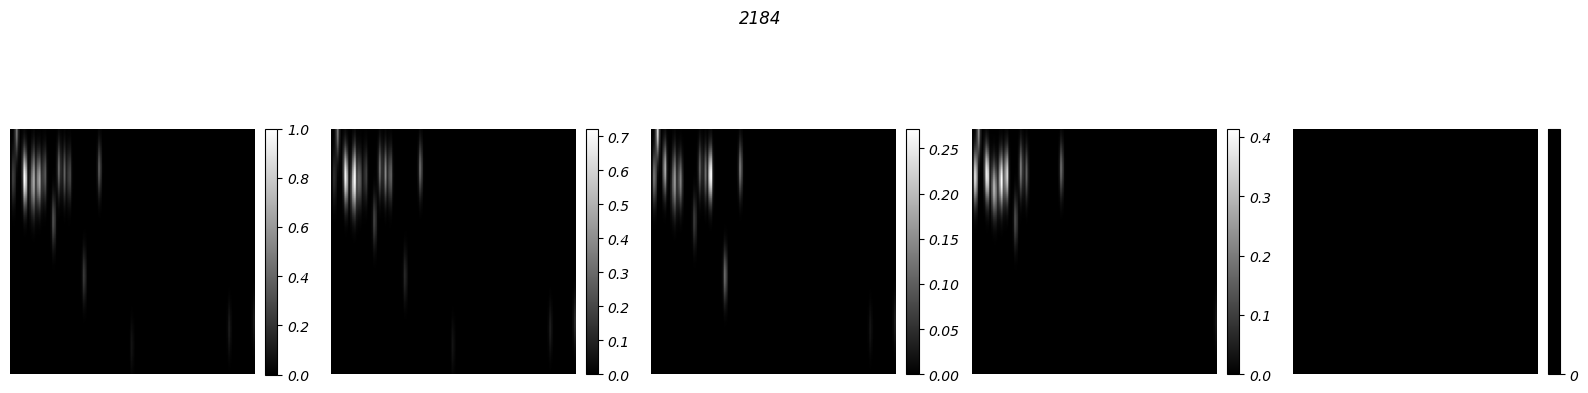

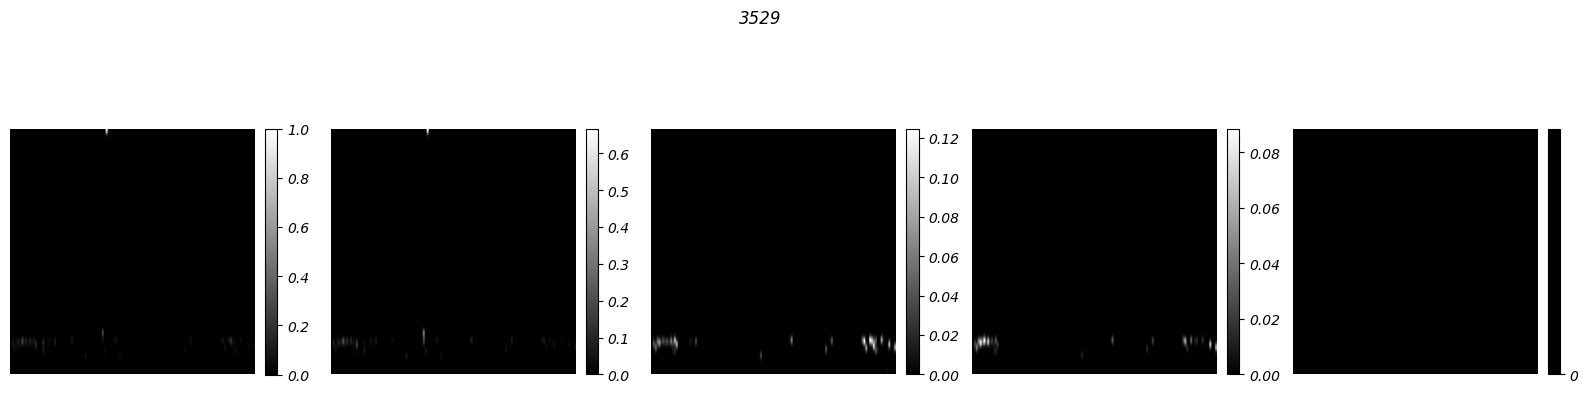

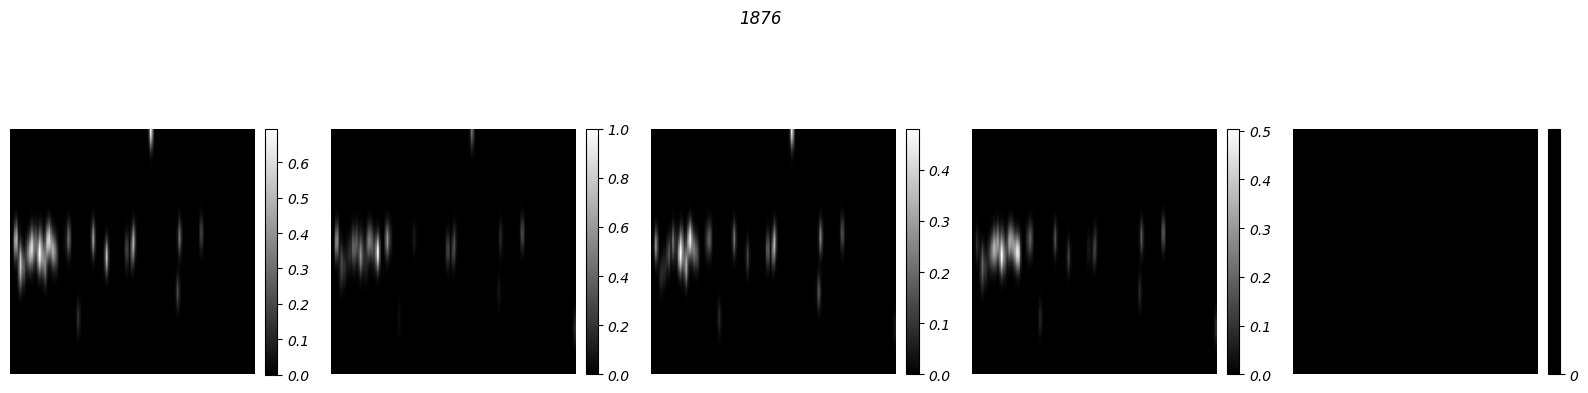

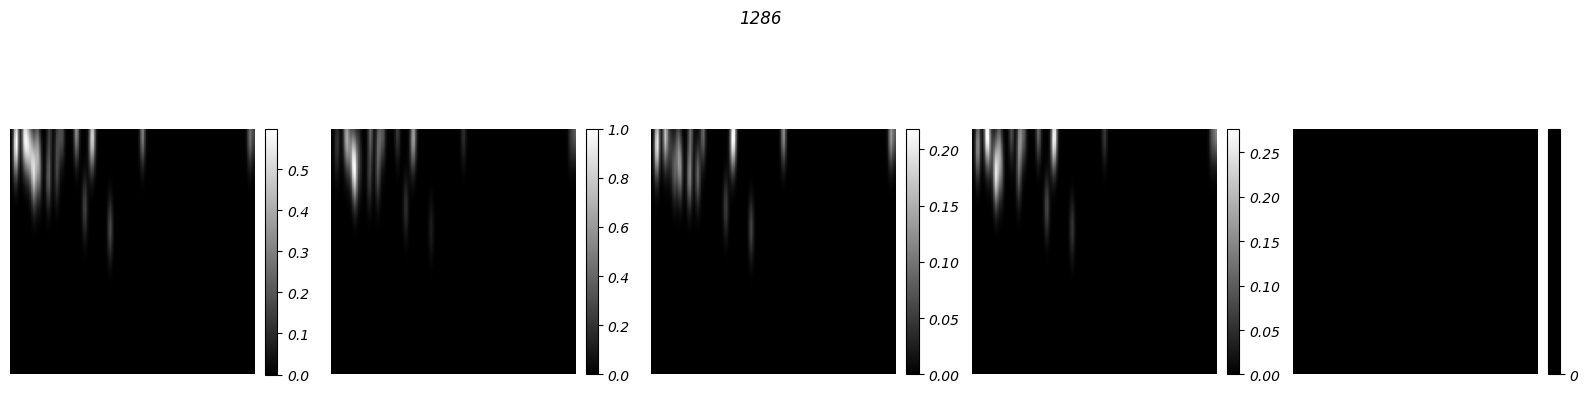

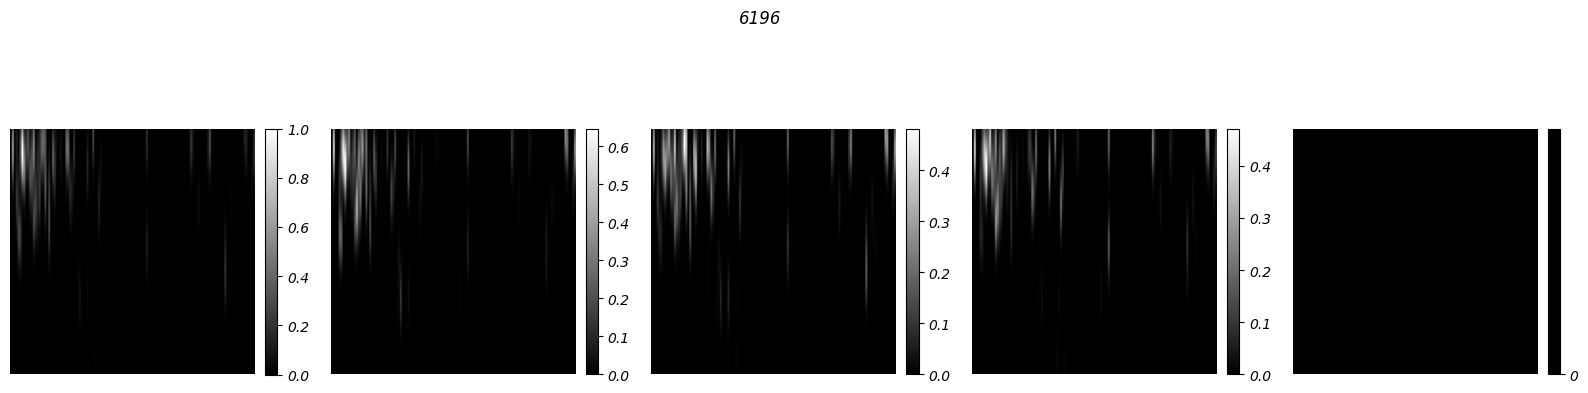

In [10]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt

for s, pi in persistence_images.items():
    five_channel_pi = pi['persistence_image']

    channel_names = ['A', 'T', 'G', 'C', 'X']
    # vmin, vmax = five_channel_pi.min(), five_channel_pi.max() # All are [0,1]
    flipped = np.flipud(five_channel_pi)

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(len(s))

    for i in range(5):
        # Index the last dimension: image_np[:, :, i]
        vmin, vmax = five_channel_pi[:,:,i].min(), five_channel_pi[:,:,i].max() 
        channel_max = flipped[:, :, i].max()

        im = axes[i].imshow(flipped[:, :, i], cmap='gray', vmin=vmin, vmax=vmax)
        
        if vmax > 0:
            fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

        if vmax == 0:
            im.set_norm(colors.Normalize(vmin=vmin, vmax=1))
            cbar = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
            cbar.ax.set_yticks([vmin])
            cbar.solids.set_color('black')
        
        axes[i].axis('off')


In [11]:
plt.close()

In [24]:
path = '/Users/levisvaren/Downloads/040326/051926/20mer'
filename = 'chunk_1.tar.gz'
k = 20

target_dict_name = 'results'

resolution = 128
sigma = 300
persistence_images = {}

with tarfile.open(f"{path}/{filename}", "r:gz") as tar:
    for member in tar:

        if target_dict_name in member.name and member.isfile():
            pkl_file = tar.extractfile(member)

            if pkl_file:
                obj = pickle.load(pkl_file)
                
                # Get barcode and sequence
                for seq, value in obj.items():
                    l = len(seq)

                    barcodes = list(value[0]['barcode_H1'])

                    if len(barcodes) > 0:
                        elements = list(value[0]['barcode_elements_H1'])
                        node_id = value[0]['node_id']
                        id_to_node = {v:k for k,v in node_id.items()}

                        ccs = [tuple(id_to_node[num] for num in t) for t in elements]

                        ###########
                        for i_seq, k_seq in enumerate([seq]):
                            results = extract_relevant_cc(k_seq, ccs, k)

                        if len(results) == 0:
                            five_channel_pi = np.zeros((resolution, resolution, 5))
                            # persistence_images[seq] = {'persistence_image': five_channel_pi}
                            # continue
                        else:
                            sequence_diagram, sequence_compositions = get_cc_b_d(seq, results, barcodes, ccs)
                            five_channel_pi = create_PI(sequence_diagram, sequence_compositions, resolution=resolution, sigma=sigma)

                    elif len(barcodes) == 0:
                        five_channel_pi = np.zeros((resolution, resolution, 5)) #Empty PI if no CCs

                    persistence_images[seq] = {'persistence_image': five_channel_pi}

In [25]:
len(persistence_images)

4927

In [ ]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt

for s, pi in persistence_images.items():
    
    five_channel_pi = pi['persistence_image']
    if five_channel_pi.max() > 0:

        channel_names = ['A', 'T', 'G', 'C', 'X']
        # vmin, vmax = five_channel_pi.min(), five_channel_pi.max() # All are [0,1]
        flipped = np.flipud(five_channel_pi)

        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        fig.suptitle(len(s))

        for i in range(5):
            # Index the last dimension: image_np[:, :, i]
            vmin, vmax = five_channel_pi[:,:,i].min(), five_channel_pi[:,:,i].max() 
            channel_max = flipped[:, :, i].max()

            im = axes[i].imshow(flipped[:, :, i], cmap='gray', vmin=vmin, vmax=vmax)
            
            if vmax > 0:
                fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

            if vmax == 0:
                im.set_norm(colors.Normalize(vmin=vmin, vmax=1))
                cbar = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
                cbar.ax.set_yticks([vmin])
                cbar.solids.set_color('black')
            
            axes[i].axis('off')
